<a href="https://colab.research.google.com/github/SUNITHACHIKKAM/Student-Performance-Analysis/blob/main/StudentPerfromanceAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import files
uploaded = files.upload()



Saving StudentsPerformance.csv to StudentsPerformance.csv


In [ ]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
#  Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [ ]:
#Step 2: Load Dataset
df = pd.read_csv("StudentsPerformance.csv")

In [ ]:
#  Step 3: Data Preprocessing
# Create average
df['average'] = (df['math score'] + df['reading score'] + df['writing score']) / 3  # Create target (Pass=1, Fail=0)
df['average'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

df['result'] = df['average'].apply(lambda x: 1 if x >= 60 else 0)

In [ ]:
 #  Step 4: Features & Target
 X = df[['math score', 'reading score', 'writing score']]
y = df['result']

In [ ]:
  # Step 5: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#  Step 6: Train Model (Random Forest )
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
  # Step 7: Prediction
y_pred = model.predict(X_test)

In [ ]:
#  Step 8: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.985

Confusion Matrix:
 [[ 62   0]
 [  3 135]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        62
           1       1.00      0.98      0.99       138

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



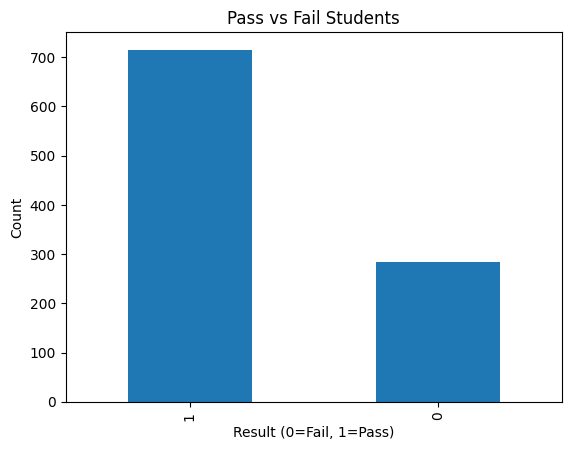

In [ ]:
  # Step 9: Visualization
df['result'].value_counts().plot(kind='bar')
plt.title("Pass vs Fail Students")
plt.xlabel("Result (0=Fail, 1=Pass)")
plt.ylabel("Count")
plt.show()

In [ ]:
#  Step 10: Overall Performance Category
def performance(avg):
    if avg >= 80:
        return "Excellent"
    elif avg >= 60:
        return "Good"
    elif avg >= 40:
        return "Average"
    else:
        return "Poor"

df['performance'] = df['average'].apply(performance)

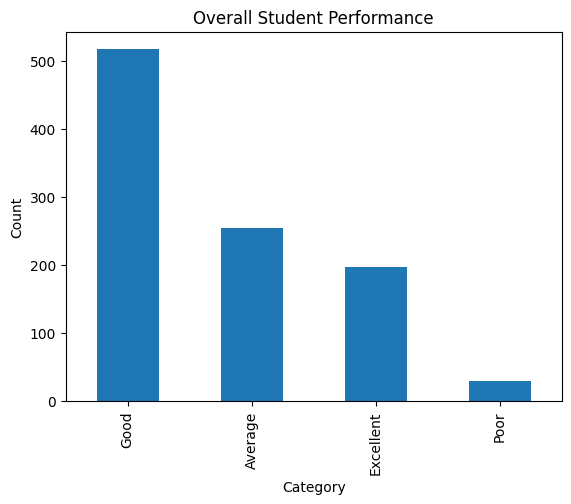

In [ ]:
#  Step 11: Performance Graph
df['performance'].value_counts().plot(kind='bar')
plt.title("Overall Student Performance")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
#  Step 12: Test Custom Input
import pandas as pd

sample = pd.DataFrame([[70, 65, 60]], columns=['math score', 'reading score', 'writing score'])

prediction = model.predict(sample)

print("Custom Student Result:", "Pass" if prediction[0]==1 else "Fail")

Custom Student Result: Pass
